# Trotterized Graph Diffusion

In [12]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import scipy
from torx import DiscretePCircuit, PSWAP, StateVectorSimulator
from tqdm import tqdm


def lighten(color, amount=0.5):
    """
    Utility function to lighten a pyplot color
    Taken from https://stackoverflow.com/questions/37765197/darken-or-lighten-a-color-in-matplotlib
    """
    import colorsys

    import matplotlib.colors as mc

    try:
        c = mc.cnames[color]
    except Exception as _:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

## Analytic heat equation on graphs

Consider the following weighted graph:

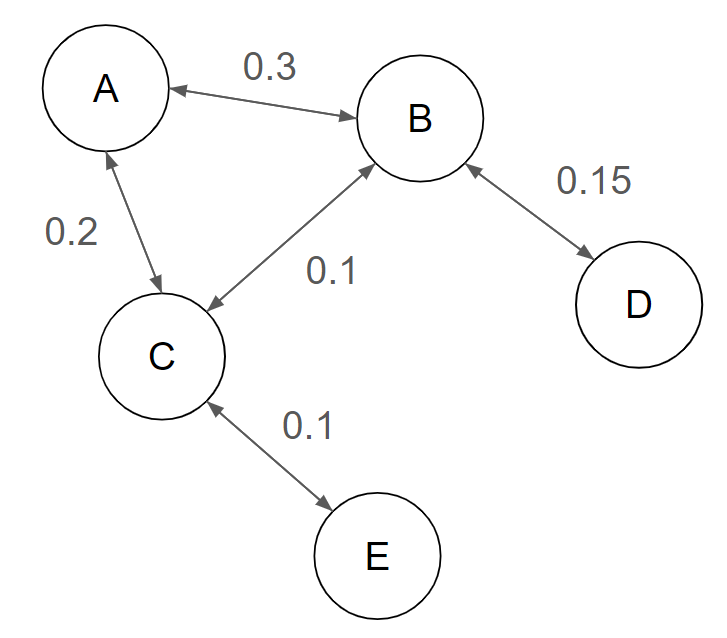

In [13]:
from IPython.display import Image

Image(filename="images/graph.PNG", width=400)

This graph has the following adjacency matrix:

$$A=\begin{pmatrix}0&0.3&0.2&0&0\\ 0.3&0&0.1&0.15&0\\ 0.2&0.1&0&0&0.1 \\ 0&0.15&0&0&0\\ 0&0&0.1&0&0 \end{pmatrix}$$

and the following degree matrix:

$$D=\begin{pmatrix}0.5&0&0&0&0\\ 0&0.55&0&0&0\\ 0&0&0.4&0&0 \\ 0&0&0&0.15&0\\ 0&0&0&0&0.1 \end{pmatrix}$$

so the graph Laplacian is

$$L=D-A=\begin{pmatrix}0.5&-0.3&-0.2&0&0\\ -0.3&0.55&-0.1&-0.15&0\\ -0.2&-0.1&0.4&0&-0.1 \\ 0&-0.15&0&0.15&0\\ 0&0&-0.1&0&0.1 \end{pmatrix}$$

Start by defining the graph:

In [14]:
probs = np.array([0.3, 0.1, 0.2, 0.15, 0.1])

adj = np.zeros((5, 5))
adj[0, 1] = probs[0]
adj[1, 2] = probs[1]
adj[0, 2] = probs[2]
adj[1, 3] = probs[3]
adj[2, 4] = probs[4]
adj = adj + adj.T
laplacian = np.diag(np.sum(adj, axis=1)) - adj

print(adj)
print(laplacian)

[[0.   0.3  0.2  0.   0.  ]
 [0.3  0.   0.1  0.15 0.  ]
 [0.2  0.1  0.   0.   0.1 ]
 [0.   0.15 0.   0.   0.  ]
 [0.   0.   0.1  0.   0.  ]]
[[ 0.5  -0.3  -0.2   0.    0.  ]
 [-0.3   0.55 -0.1  -0.15  0.  ]
 [-0.2  -0.1   0.4   0.   -0.1 ]
 [ 0.   -0.15  0.    0.15  0.  ]
 [ 0.    0.   -0.1   0.    0.1 ]]


Now suppose we have some distribution $\phi(v_i,t)$ on the vertices $V$ of the graph. The distribution diffuses across the graph according to the [heat equation](https://simonensemble.github.io/pluto_nbs/graph_diffusion_blog.jl.html):

$$\frac{d\phi}{dt}=-\alpha L\phi$$

where $L$ is the graph Laplacian and $\alpha$ is a constant called the thermal diffusivity, which we hereafter set to $1$. The solution is

$$\phi(t)=\exp(-Lt)\phi(0)$$

Given our above graph and an initial density that is entirely on vertex $A$, we can visualize how the density changes as a function of time:

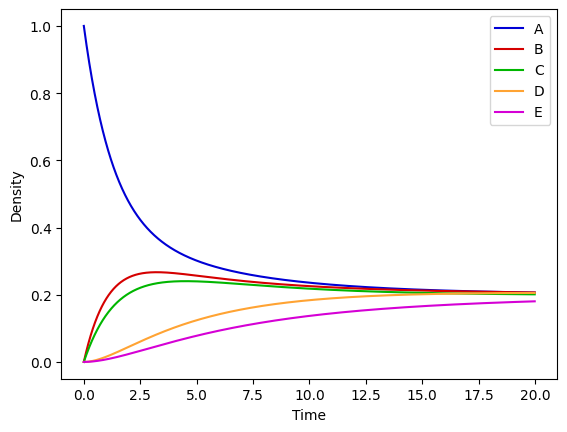

In [15]:
initial_density = np.array([1, 0, 0, 0, 0])
colors = ["darkblue", "darkred", "darkgreen", "darkorange", "darkmagenta"]

T = 20
t = np.arange(0, T, 0.01)

heat_equation_densities = (
    scipy.linalg.expm(-laplacian[None, :] * t[:, None, None]) @ initial_density
)

plt.plot(t, heat_equation_densities[:, 0], label="A", c=lighten(colors[0], 0.8))
plt.plot(t, heat_equation_densities[:, 1], label="B", c=lighten(colors[1], 0.8))
plt.plot(t, heat_equation_densities[:, 2], label="C", c=lighten(colors[2], 0.8))
plt.plot(t, heat_equation_densities[:, 3], label="D", c=lighten(colors[3], 0.8))
plt.plot(t, heat_equation_densities[:, 4], label="E", c=lighten(colors[4], 0.8))
plt.legend(loc="best")
plt.xlabel("Time")
plt.ylabel("Density")
plt.show()

As expected, we see that the heat diffuses across the graph and approaches the uniform distribution.

## Probabilistic circuit implementation

We can implement diffusion on a graph as a probabilistic circuit, simply by defining a pbit for each vertex in the graph and adding a PSWAP with probability $p$ between any two vertices connected by an edge with weight $p$. For the above graph, the circuit looks like the following:

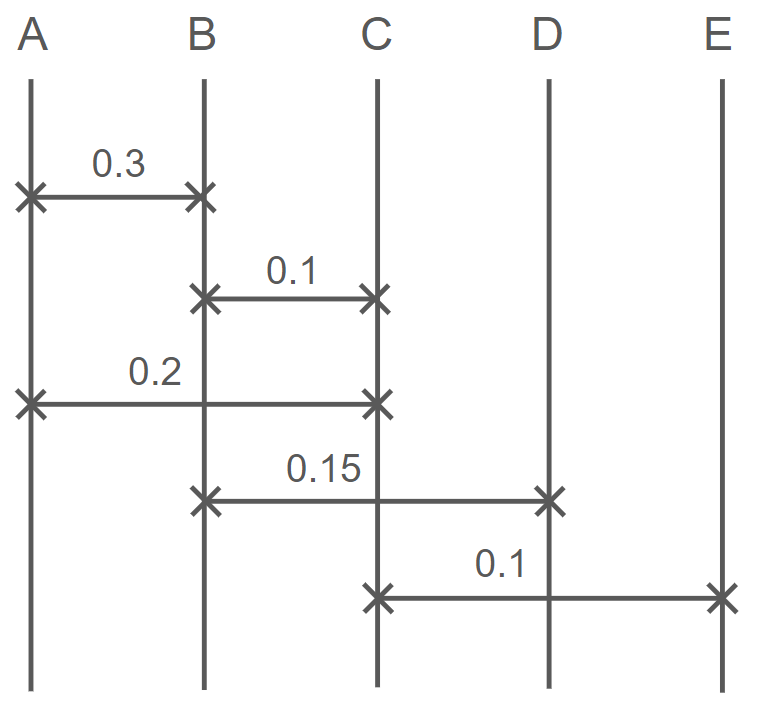

In [16]:
Image(filename="images/pcircuit.PNG", width=400)

One issue with this approach is that the PSWAPs do not commute: the order in which the PSWAPs are applied makes a difference in the output of the circuit. We may mitigate this issue by _Trotterizing_ it. Instead of simply implementing the above circuit, we implement $N$ sequential copies of the circuit while at the same time dividing the probabilities by $N$. As $N$ increases, we obtain a better approximation to the continuum limit.

Below we can see the effect of the number of Trotter steps (per unit time) on the distribution as a function of time. We also plot the analytic solution on the same graph for comparison:

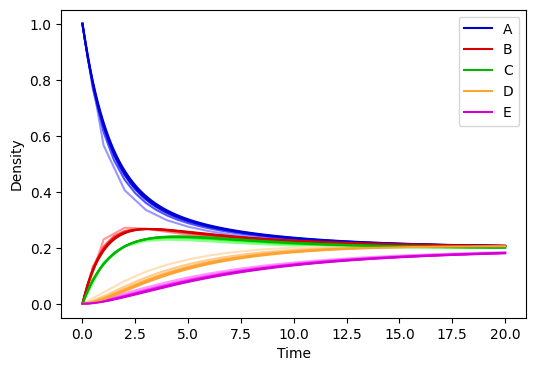

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sim = StateVectorSimulator()
sim_fn = eqx.filter_jit(sim.density)

for i, trotter_steps in enumerate([1, 2, 4, 8], start=1):
    trotter_probs = probs / trotter_steps
    trotter_params = -np.log(1 / trotter_probs - 1)

    walk_layer = [
        PSWAP(jnp.array(trotter_params[0]), [0, 1]),
        PSWAP(jnp.array(trotter_params[1]), [1, 2]),
        PSWAP(jnp.array(trotter_params[2]), [0, 2]),
        PSWAP(jnp.array(trotter_params[3]), [1, 3]),
        PSWAP(jnp.array(trotter_params[4]), [2, 4]),
    ]

    circuit = DiscretePCircuit(walk_layer)

    # [1, 0, 0, 0, 0]
    state = jnp.zeros(32).at[16].set(1)
    trotter_densities = [initial_density]

    for _ in range(T * trotter_steps):
        state = sim_fn(circuit, state)
        trotter_densities.append([state[16], state[8], state[4], state[2], state[1]])

    trotter_densities = np.array(trotter_densities)

    plt.plot(
        np.arange(trotter_densities.shape[0]) / trotter_steps,
        trotter_densities[:, 0],
        c=lighten(colors[0], 0.1 + 0.18 * i),
    )
    plt.plot(
        np.arange(trotter_densities.shape[0]) / trotter_steps,
        trotter_densities[:, 1],
        c=lighten(colors[1], 0.1 + 0.18 * i),
    )
    plt.plot(
        np.arange(trotter_densities.shape[0]) / trotter_steps,
        trotter_densities[:, 2],
        c=lighten(colors[2], 0.1 + 0.18 * i),
    )
    plt.plot(
        np.arange(trotter_densities.shape[0]) / trotter_steps,
        trotter_densities[:, 3],
        c=lighten(colors[3], 0.1 + 0.18 * i),
    )
    plt.plot(
        np.arange(trotter_densities.shape[0]) / trotter_steps,
        trotter_densities[:, 4],
        c=lighten(colors[4], 0.1 + 0.18 * i),
    )

# re-plot the above analytic solution for comparison
plt.plot(t, heat_equation_densities[:, 0], label="A", c=lighten(colors[0], 0.8))
plt.plot(t, heat_equation_densities[:, 1], label="B", c=lighten(colors[1], 0.8))
plt.plot(t, heat_equation_densities[:, 2], label="C", c=lighten(colors[2], 0.8))
plt.plot(t, heat_equation_densities[:, 3], label="D", c=lighten(colors[3], 0.8))
plt.plot(t, heat_equation_densities[:, 4], label="E", c=lighten(colors[4], 0.8))

plt.legend(loc="best")
plt.xlabel("Time")
plt.ylabel("Density")
plt.show()

As expected, we see that as the number of Trotter steps increases, the diffusion approaches the analytic solution to the heat equation. At 8 Trotter steps per unit time, the error between the probabilistic circuit and the analytic solution is almost negligible. 

## Training edge weights

Since probabilistic circuits are fully differentiable, we can use them in a training pipeline to optimize some loss function via gradient descent. 

As a toy problem, suppose that we have the same graph as before but where the edge weights are trainable. Our objective is to maximize the density of vertex $E$ after 10 units of time.

In [18]:
# sim = SampleSimulator(num_samples=1000)
sim = StateVectorSimulator()
T = 10


@jax.value_and_grad
def loss_fn(params, key):
    trotter_steps = 16

    probs = 1 / (1 + jnp.exp(-params))
    trotter_probs = probs / trotter_steps
    trotter_params = -jnp.log(1 / trotter_probs - 1 + 1e-7)

    walk_layer = [
        PSWAP(jnp.array(trotter_params[0]), [0, 1]),
        PSWAP(jnp.array(trotter_params[1]), [1, 2]),
        PSWAP(jnp.array(trotter_params[2]), [0, 2]),
        PSWAP(jnp.array(trotter_params[3]), [1, 3]),
        PSWAP(jnp.array(trotter_params[4]), [2, 4]),
    ]

    circuit = DiscretePCircuit(walk_layer, reps=T * trotter_steps)
    # circuit = DiscretePCircuit(walk_layer * T * trotter_steps)

    # expval = sim.expval(circuit, jnp.array([1.0, 0, 0, 0, 0]), pbit=4, key=key)
    expval = sim.expval(circuit, jnp.zeros(32).at[16].set(1), pbit=4)
    return -expval


@jax.jit
def do_step(params, key, opt_state):
    key, new_key = jax.random.split(key, 2)
    loss, grads = loss_fn(params, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, new_key, opt_state, loss


key = jax.random.key(1002)
optimizer = optax.adam(learning_rate=1e-2)

params = jax.random.uniform(key, shape=(5,), minval=-1, maxval=1)
opt_state = optimizer.init(params)
ntrainsteps = 5000
losses = []
train_loop = tqdm(range(ntrainsteps))
for step in train_loop:
    params, key, opt_state, loss = do_step(params, key, opt_state)
    losses.append(loss)
    train_loop.set_description(f"Step {step + 1}, Loss {loss:.6f}")

print(f"Final probs: {1 / (1 + jnp.exp(-params))}")

  0%|          | 0/5000 [00:00<?, ?it/s]

Step 5000, Loss -0.333249: 100%|██████████| 5000/5000 [00:40<00:00, 122.23it/s]

Final probs: [3.7679220e-05 2.1907417e-05 9.8015195e-01 4.0890276e-02 9.2180640e-01]


As expected, we see that the circuit learns to transition from $A$ to $C$ and from $C$ to $E$ with close to $100\%$ probability, making the final distribution a near-uniform distribution between the three vertices $A$, $C$, and $E$.

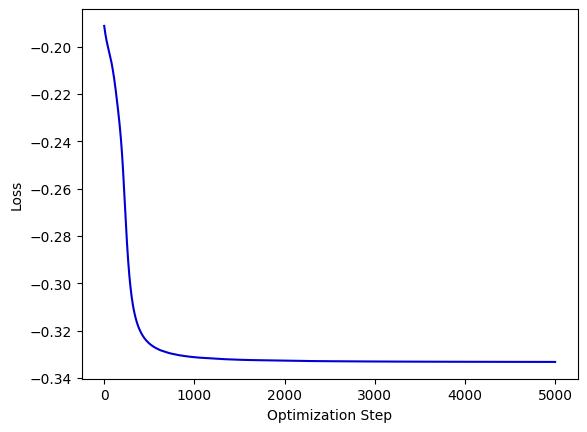

In [19]:
plt.plot(range(ntrainsteps), losses, c=lighten(colors[0], 0.8))
plt.xlabel("Optimization Step")
plt.ylabel("Loss")
plt.show()